# Hello Stitch-OPE

A toy walkthrough of the **STITCH-OPE** pipeline on a D4RL locomotion task.

STITCH-OPE is a model-based generative framework for **off-policy evaluation (OPE)**:
given offline data collected by a *behavior policy*, estimate the expected return of a
different *target policy* — without ever running the target policy in the real environment.

### How it works (high level)

1. **Train a trajectory diffusion model** on offline (state, action) chunks from D4RL.
2. **Sample synthetic trajectories** using the diffusion model, *guided* by the target policy's
   score function (classifier-free guidance style). The guidance steers generated actions toward
   what the target policy would do, while optionally *subtracting* behavior policy scores to
   avoid over-regularization toward the data distribution.
3. **Stitch chunks** end-to-end: condition each new chunk on the final state of the previous one,
   building full-length trajectories from short diffusion windows.
4. **Evaluate**: compute discounted returns on the synthetic trajectories using a learned
   reward estimator. The mean return is the OPE estimate.

### This notebook

| Section | What it does |
|---------|-------------|
| 1 | Load D4RL dataset, inspect it, compute normalization stats |
| 2 | Train a small TemporalUnet diffusion model on trajectory chunks |
| 3 | Sample trajectories with and without policy guidance |
| 4 | Compare: unguided vs guided trajectory distributions |

**Requirements**: `latent_sope` conda env with D4RL installed.

## 1. Load D4RL dataset and compute normalization

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_ROOT = Path("../").resolve()
SOPE_ROOT = REPO_ROOT / "third_party" / "sope"
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(SOPE_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [2]:
import gym
import d4rl  # noqa: F401  (registers D4RL envs)

ENV_NAME = "hopper-medium-v2"
env = gym.make(ENV_NAME)
dataset = env.get_dataset()

obs = dataset["observations"]       # (N, obs_dim)
actions = dataset["actions"]         # (N, action_dim)
rewards = dataset["rewards"]         # (N,)
terminals = dataset["terminals"]     # (N,)
timeouts = dataset["timeouts"]       # (N,)

obs_dim = obs.shape[1]
action_dim = actions.shape[1]
print(f"Env: {ENV_NAME}")
print(f"  obs_dim={obs_dim}, action_dim={action_dim}")
print(f"  dataset size: {obs.shape[0]} transitions")
print(f"  obs  range: [{obs.min():.2f}, {obs.max():.2f}]")
print(f"  act  range: [{actions.min():.2f}, {actions.max():.2f}]")
print(f"  reward range: [{rewards.min():.2f}, {rewards.max():.2f}]")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
These new versions include large bug fixes, new versions of Python, and are where all new development will continue. Please upgrade these libraries as soon as you're able to do so.
If you'd like to read more about the story behind this switch, please check out ]8;;https://farama.org/Announcing-Minari\this blog post]8;;\.
/home1/reishuen/miniconda3/envs/latent_sope/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_

Env: hopper-medium-v2
  obs_dim=11, action_dim=3
  dataset size: 1000000 transitions
  obs  range: [-10.00, 10.00]
  act  range: [-1.00, 1.00]
  reward range: [0.55, 5.94]


In [3]:
# Split dataset into episodes at terminal/timeout boundaries
episode_ends = np.where(terminals | timeouts)[0] + 1
episode_starts = np.concatenate([[0], episode_ends[:-1]])

episodes = []
for start, end in zip(episode_starts, episode_ends):
    episodes.append({
        "observations": obs[start:end],
        "actions": actions[start:end],
        "rewards": rewards[start:end],
    })

ep_lens = [len(ep["rewards"]) for ep in episodes]
ep_returns = [ep["rewards"].sum() for ep in episodes]
print(f"{len(episodes)} episodes, lengths: {np.min(ep_lens)}-{np.max(ep_lens)} (mean {np.mean(ep_lens):.0f})")
print(f"Returns: mean={np.mean(ep_returns):.1f}, std={np.std(ep_returns):.1f}")

2186 episodes, lengths: 145-1000 (mean 457)
Returns: mean=1422.1, std=379.0


In [4]:
# Compute normalization stats (same as SOPE's compute_normalization)
transitions = np.concatenate([obs, actions], axis=-1)  # (N, obs_dim + action_dim)
transition_dim = transitions.shape[1]

data_mean = transitions.mean(axis=0)
data_std  = transitions.std(axis=0) + 1e-6

mean_t = torch.tensor(data_mean, dtype=torch.float32, device=device)
std_t  = torch.tensor(data_std,  dtype=torch.float32, device=device)

normalize   = lambda x: (x - mean_t) / std_t
unnormalize = lambda x: x * std_t + mean_t

print(f"transition_dim = {transition_dim} (obs={obs_dim} + act={action_dim})")

transition_dim = 14 (obs=11 + act=3)


## 2. Train a trajectory chunk diffusion model

We use `TemporalUnet` + `GaussianDiffusion` from `third_party/sope`.
The model learns to denoise (state, action) trajectory chunks of length `T`.

This is a **small toy** — we train for a few hundred steps on short chunks.
Real SOPE training uses much longer training and larger models.

In [5]:
from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion

T = 8              # chunk horizon (number of timesteps per chunk)
D = 64             # diffusion timesteps (small for toy)
BATCH_SIZE = 256
TRAIN_STEPS = 500  # increase for better quality (1000+ recommended)
LR = 3e-4

# Build model
unet = TemporalUnet(
    horizon=T,
    transition_dim=transition_dim,
    dim_mults=(1, 2, 4),
    attention=False,
).to(device)

diffusion = GaussianDiffusion(
    model=unet,
    horizon=T,
    observation_dim=obs_dim,
    action_dim=action_dim,
    n_timesteps=D,
    normalizer=normalize,
    unnormalizer=unnormalize,
    predict_epsilon=True,
    loss_type="l2",
    action_weight=5.0,
    loss_discount=1.0,
).to(device)

n_params = sum(p.numel() for p in diffusion.parameters())
print(f"TemporalUnet params: {n_params:,}")
print(f"Chunk horizon T={T}, diffusion steps D={D}")

[ models/temporal ] Channel dimensions: [(14, 32), (32, 64), (64, 128)]
[(14, 32), (32, 64), (64, 128)]
TemporalUnet params: 999,374
Chunk horizon T=8, diffusion steps D=64


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


In [6]:
def sample_training_chunks(episodes, T, batch_size):
    """Sample random (state, action) chunks of length T from episodes."""
    chunks = []
    while len(chunks) < batch_size:
        ep = episodes[np.random.randint(len(episodes))]
        ep_len = len(ep["rewards"])
        if ep_len < T:
            continue
        start = np.random.randint(0, ep_len - T + 1)
        chunk_obs = ep["observations"][start:start + T]    # (T, obs_dim)
        chunk_act = ep["actions"][start:start + T]          # (T, action_dim)
        chunk = np.concatenate([chunk_obs, chunk_act], axis=-1)  # (T, transition_dim)
        chunks.append(chunk)
    return torch.tensor(np.array(chunks[:batch_size]), dtype=torch.float32, device=device)

# Quick sanity check
batch = sample_training_chunks(episodes, T, 4)
print(f"Training chunk shape: {batch.shape}  (batch, T, transition_dim)")

Training chunk shape: torch.Size([4, 8, 14])  (batch, T, transition_dim)


Training diffusion:   0%|          | 0/500 [00:00<?, ?it/s]

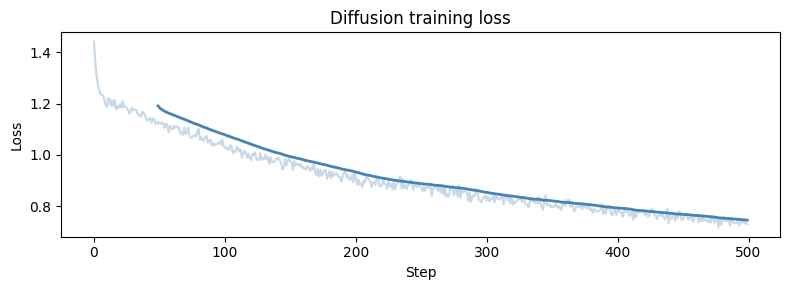

Final loss: 0.7463


In [7]:
from tqdm.auto import tqdm

optimizer = torch.optim.Adam(diffusion.parameters(), lr=LR)
losses = []

diffusion.train()
for step in tqdm(range(1, TRAIN_STEPS + 1), desc="Training diffusion"):
    batch = sample_training_chunks(episodes, T, BATCH_SIZE)
    # Normalize
    batch_norm = normalize(batch)
    # Condition on first state (standard SOPE conditioning)
    cond = {0: batch_norm[:, 0, :obs_dim]}
    loss, info = diffusion.loss(batch_norm, cond)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(diffusion.parameters(), 1.0)
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(losses, alpha=0.3, color="steelblue")
# Smoothed
window = min(50, len(losses) // 5)
if window > 1:
    smoothed = np.convolve(losses, np.ones(window)/window, mode="valid")
    plt.plot(range(window-1, len(losses)), smoothed, color="steelblue", linewidth=2)
plt.xlabel("Step"); plt.ylabel("Loss"); plt.title("Diffusion training loss")
plt.tight_layout(); plt.show()
print(f"Final loss: {np.mean(losses[-50:]):.4f}")

## 3. Sample trajectories: unguided vs policy-guided

Now we sample trajectory chunks from the trained diffusion model:

- **Unguided** (`guided=False`): samples from the data distribution (behavior policy)
- **Guided** (`guided=True`): samples steered toward the *target policy* using its
  score function as classifier-free guidance, with optional behavior-policy subtraction

We also demonstrate **chunk stitching**: conditioning each new chunk on the final
state of the previous chunk to build longer trajectories.

In [8]:
# Use D4RL's behavior policy as a simple stand-in
from opelab.core.policy import D4RLPolicy

behavior_policy = D4RLPolicy(ENV_NAME).to(device)
diffusion.policy = behavior_policy           # target policy for guidance
diffusion.behavior_policy = behavior_policy   # behavior policy (for neg grad subtraction)

# In real SOPE, target_policy != behavior_policy. Here we use the same one
# just to demonstrate the mechanics. With a *different* target policy,
# the guided samples would shift toward that policy's preferred actions.
print(f"Loaded D4RL behavior policy for {ENV_NAME}")

/home1/reishuen/miniconda3/envs/latent_sope/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


medium


load datafile: 100%|██████████| 21/21 [00:01<00:00, 14.25it/s]


dict_keys(['actions', 'infos/action_log_probs', 'infos/qpos', 'infos/qvel', 'metadata/algorithm', 'metadata/iteration', 'metadata/policy/fc0/bias', 'metadata/policy/fc0/weight', 'metadata/policy/fc1/bias', 'metadata/policy/fc1/weight', 'metadata/policy/last_fc/bias', 'metadata/policy/last_fc/weight', 'metadata/policy/last_fc_log_std/bias', 'metadata/policy/last_fc_log_std/weight', 'metadata/policy/nonlinearity', 'metadata/policy/output_distribution', 'next_observations', 'observations', 'rewards', 'terminals', 'timeouts'])
Total log probability for the episode: 1210.7517310082912
Loaded D4RL behavior policy for hopper-medium-v2


In [9]:
diffusion.eval()
NUM_SAMPLES = 16

# Pick a real starting state from the dataset
start_idx = np.random.randint(len(episodes))
init_state = torch.tensor(
    episodes[start_idx]["observations"][0],
    dtype=torch.float32, device=device,
)
init_state_norm = (init_state - mean_t[:obs_dim]) / std_t[:obs_dim]
cond = {0: init_state_norm.unsqueeze(0).expand(NUM_SAMPLES, -1)}

# --- Unguided sampling ---
with torch.no_grad():
    samples_unguided = diffusion.conditional_sample(
        shape=(NUM_SAMPLES, T, transition_dim),
        cond=cond,
        guided=False,
    )
trajs_unguided = unnormalize(samples_unguided.trajectories)
print(f"Unguided samples: {trajs_unguided.shape}")

# --- Guided sampling ---
guidance_hyperparams = {
    "action_scale": 0.5,
    "use_adaptive": False,
    "use_neg_grad": True,
    "neg_grad_scale": 0.1,
    "normalize_grad": True,
    "k_guide": 1,
    "use_action_grad_only": True,
    "clamp": True,
    "l_inf": 1.0,
    "ratio": 0.5,
}
samples_guided = diffusion.conditional_sample(
    shape=(NUM_SAMPLES, T, transition_dim),
    cond=cond,
    guided=True,
    **guidance_hyperparams,
)
trajs_guided = unnormalize(samples_guided.trajectories)
print(f"Guided samples:   {trajs_guided.shape}")


                                                                                                    
1 / 64 [                                                            ]   1% | 14.5 Hz
t : 63
                                                                                                    
                                                                                                    
2 / 64 [#                                                           ]   3% | 24.8 Hz
t : 62
                                                                                                    
                                                                                                    
3 / 64 [##                                                          ]   4% | 32.4 Hz
t : 61
                                                                                                    
                                                                                                    
4 / 64 [###     

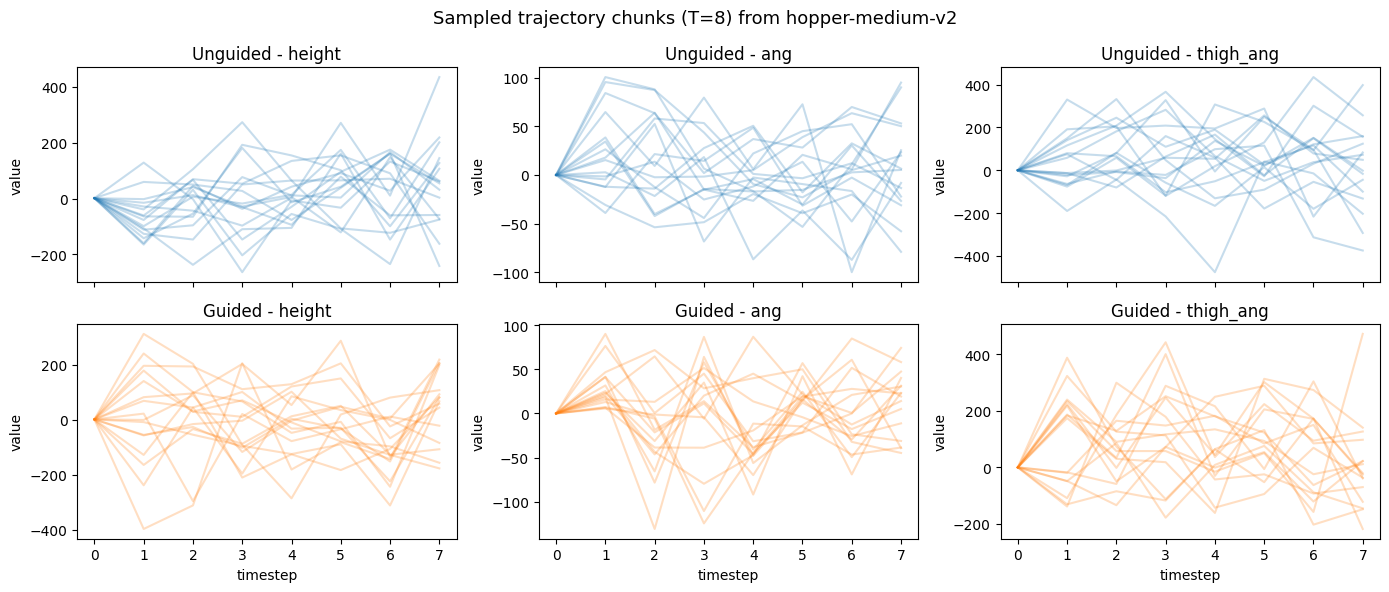

In [10]:
# Visualize: compare a few state dimensions over the chunk horizon
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
dim_names = ["height", "ang", "thigh_ang", "leg_ang", "foot_ang", "vel_x"]
dims_to_plot = list(range(min(6, obs_dim)))

for col, d in enumerate(dims_to_plot[:3]):
    ax = axes[0, col]
    for i in range(NUM_SAMPLES):
        ax.plot(trajs_unguided[i, :, d].cpu(), alpha=0.25, color="tab:blue")
    ax.set_title(f"Unguided - {dim_names[d]}")
    ax.set_ylabel("value")

for col, d in enumerate(dims_to_plot[:3]):
    ax = axes[1, col]
    for i in range(NUM_SAMPLES):
        ax.plot(trajs_guided[i, :, d].cpu(), alpha=0.25, color="tab:orange")
    ax.set_title(f"Guided - {dim_names[d]}")
    ax.set_xlabel("timestep")
    ax.set_ylabel("value")

fig.suptitle(f"Sampled trajectory chunks (T={T}) from {ENV_NAME}", fontsize=13)
plt.tight_layout(); plt.show()

## 4. Chunk stitching: build longer trajectories

SOPE generates long trajectories by **stitching** short diffusion chunks:

1. Sample a chunk of length `T` conditioned on `s_0`
2. Take the final state `s_T` of that chunk
3. Sample a new chunk conditioned on `s_T`
4. Repeat until desired trajectory length or termination

This is what `Diffuser.generate_full_trajectory()` does under the hood.

In [13]:
def hopper_is_terminated(state_np):
    """Hopper termination check (same as SOPE's terminate_fn)."""
    height, ang = state_np[0], state_np[1]
    return not (
        np.isfinite(state_np).all()
        and (np.abs(state_np[2:]) < 100).all()
        and height > 0.7
        and abs(ang) < 0.2
    )


def stitch_trajectory(diffusion, init_state_norm, obs_dim, transition_dim, T,
                      mean_t, std_t, max_chunks=20, guided=False, **guidance_kw):
    """Generate a long trajectory by stitching diffusion chunks."""
    all_states = []
    all_actions = []
    current_state_norm = init_state_norm.clone()  # (obs_dim,)

    for chunk_i in range(max_chunks):
        cond = {0: current_state_norm.unsqueeze(0)}  # (1, obs_dim)
        with torch.no_grad():
            sample = diffusion.conditional_sample(
                shape=(1, T, transition_dim),
                cond=cond,
                guided=guided,
                **guidance_kw,
            )
        chunk = sample.trajectories[0]  # (T, transition_dim) normalized
        chunk_unnorm = chunk * std_t + mean_t

        states  = chunk_unnorm[:, :obs_dim].cpu().numpy()
        actions = chunk_unnorm[:, obs_dim:].cpu().numpy()

        for t in range(T):
            if hopper_is_terminated(states[t]):
                return np.array(all_states), np.array(all_actions), True
            all_states.append(states[t])
            all_actions.append(actions[t])

        # Stitch: condition next chunk on this chunk's final state
        last_state = chunk[-1, :obs_dim]  # already normalized
        current_state_norm = last_state

    return np.array(all_states), np.array(all_actions), False


# Generate a few stitched trajectories
NUM_TRAJS = 8
MAX_CHUNKS = 30  # T * MAX_CHUNKS = max trajectory length

stitched_trajs = []
for i in range(NUM_TRAJS):
    ep = episodes[np.random.randint(len(episodes))]
    s0 = torch.tensor(ep["observations"][0], dtype=torch.float32, device=device)
    s0_norm = (s0 - mean_t[:obs_dim]) / std_t[:obs_dim]
    
    states, actions, terminated = stitch_trajectory(
        diffusion, s0_norm, obs_dim, transition_dim, T,
        mean_t, std_t, max_chunks=MAX_CHUNKS, guided=False,
    )
    stitched_trajs.append((states, actions, terminated))
    status = "terminated" if terminated else f"reached max ({T * MAX_CHUNKS} steps)"
    print(f"  Traj {i}: {len(states)} steps, {status}")

print(f"\nGenerated {NUM_TRAJS} stitched trajectories (T={T}, max_chunks={MAX_CHUNKS})")


                                                                                                    
1 / 64 [                                                            ]   1% | 71.2 Hz
t : 63
                                                                                                    
                                                                                                    
2 / 64 [#                                                           ]   3% | 75.6 Hz
t : 62
                                                                                                    
                                                                                                    
3 / 64 [##                                                          ]   4% | 76.9 Hz
t : 61
                                                                                                    
                                                                                                    
4 / 64 [###     

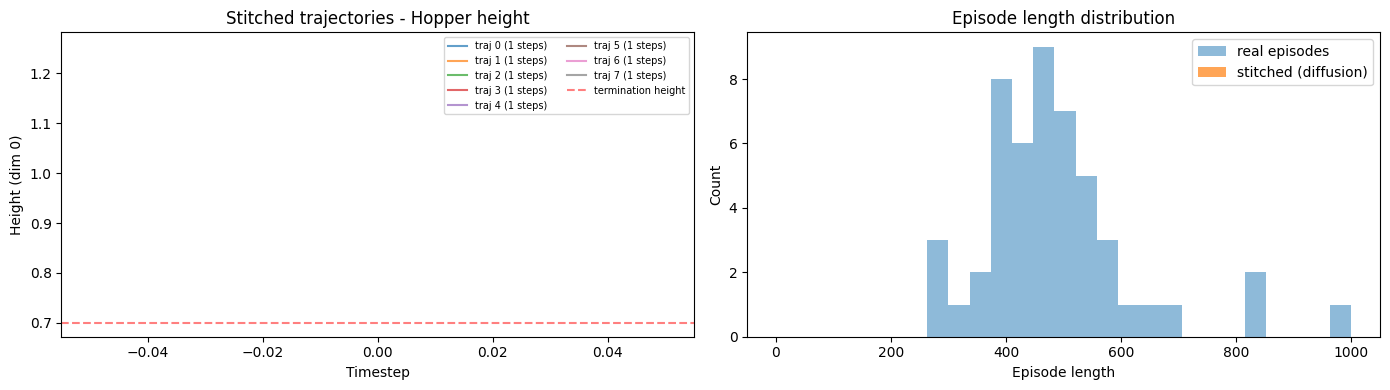

In [14]:
# Plot stitched trajectories: height over time (dim 0 for Hopper)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for i, (states, actions, terminated) in enumerate(stitched_trajs):
    color = f"C{i}"
    ax.plot(states[:, 0], color=color, alpha=0.7, label=f"traj {i} ({len(states)} steps)")
    # Mark chunk boundaries
    for cb in range(T, len(states), T):
        ax.axvline(cb, color=color, alpha=0.1, linewidth=0.5)
ax.axhline(0.7, color="red", linestyle="--", alpha=0.5, label="termination height")
ax.set_xlabel("Timestep")
ax.set_ylabel("Height (dim 0)")
ax.set_title("Stitched trajectories - Hopper height")
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
traj_lens = [len(s) for s, _, _ in stitched_trajs]
real_lens = [len(ep["rewards"]) for ep in episodes[:50]]
ax.hist(real_lens, bins=20, alpha=0.5, label="real episodes", color="tab:blue")
ax.hist(traj_lens, bins=10, alpha=0.7, label="stitched (diffusion)", color="tab:orange")
ax.set_xlabel("Episode length")
ax.set_ylabel("Count")
ax.set_title("Episode length distribution")
ax.legend()

plt.tight_layout(); plt.show()

## Summary

This notebook demonstrated the core STITCH-OPE mechanics:

1. **Trajectory diffusion**: A `TemporalUnet` trained on (state, action) chunks from offline data
2. **Conditional generation**: Conditioning on initial states to sample plausible continuations
3. **Policy guidance**: Steering samples toward a target policy using score-function gradients
4. **Chunk stitching**: Building long trajectories by chaining short diffusion windows

In the full SOPE pipeline (`opelab/examples/d4rl/main_full.py`), these generated trajectories
are scored with a learned reward estimator to produce an OPE value estimate for the target policy.

### Next steps
- Train for more steps (1000+) for higher-quality samples
- Use a *different* target policy (e.g., load a SAC policy) to see guidance shift the distribution
- Run the full evaluation pipeline with `evaluate_policies()` from `opelab/examples/helpers.py`